# Local capture and leakage in event-driven urban spending

**A sensitivity analysis of a visitor dollar's path through a host-city economy**

---

## Motivation

Cities that host large sporting events publish detailed economic impact projections
in advance and almost never verify them afterward. The 2026 FIFA World Cup was hosted
across sixteen North American cities with projections in the tens of billions; several
host cities — Miami, Dallas, Los Angeles, Boston — created supplier programs
specifically to route procurement toward local and diverse businesses. Whether those
programs changed anything is largely unknown.

Part of the difficulty is that "economic impact" is usually reported as a total, and a
total cannot distinguish between a dollar that circulates six times within a
neighborhood and a dollar that leaves the region on its first transaction. Those are
very different outcomes for the community, and they are a question about network
structure rather than about magnitude.

## What this notebook does

It models a visitor dollar entering a host-city economy as an **absorbing Markov chain**
over business and institutional nodes, with a single absorbing state representing exit
from the regional economy. From that structure it computes, exactly, the expected number
of local transactions a dollar generates before it leaves.

**The transition probabilities are not known.** No public dataset gives the share of
stadium-district spending captured by independent businesses, or the share of independent
business revenue paid as local wages. So this notebook does not assert values for them.
Instead it treats them as parameters and sweeps them, so that the conclusion takes the
form *"retention is highly sensitive to X and insensitive to Y"* — a structural claim that
does not depend on knowing the true values.

## Three methodological choices worth stating

**1. The metric counts circulation, not contact.** A natural but misleading measure is
whether a dollar ever *touches* a local business. Under that measure, a dollar that goes
visitor → local bar → national supplier → exit counts as a success, even though it left
immediately. The primary metric here is the expected *number* of local transactions per
entering dollar. Both are computed below so the difference is visible.

**2. The solution is analytic, not simulated.** For an absorbing Markov chain, expected
visits to each transient state have a closed form via the fundamental matrix
$N = (I - Q)^{-1}$. Monte Carlo is included only to validate the linear algebra.

**3. Parameters are swept, not asserted.** Point estimates from invented parameters are
not findings. The sensitivity analysis is the analysis.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

import leakage as L

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

## 1. The network

Ten states. Nine transient, one absorbing (`exits_region`). Local nodes are the
independent businesses and household-income nodes whose transactions represent money
still circulating in the regional economy.

The structure encodes a few substantive assumptions that are worth making explicit,
since they are stronger than the parameter values:

- Venue and official-channel spending has only two destinations: out of region, or
  municipal tax. There is no path from venue revenue to independent local business.
  This reflects the concessionaire and league revenue-sharing structure typical of
  major venues.
- Every path eventually reaches `exits_region`. The chain is absorbing by construction,
  so "all money eventually leaves" is an assumption, not a result. The question is how
  many local transactions happen first.
- Recirculation loops exist (wages → grocery → wages, resident spending → bar), which
  is what makes expected-visit counts exceed one.

In [2]:
P, states = L.build_transition_matrix(L.BASELINE)

print(f"States ({len(states)}):")
for s in states:
    tag = "  [local]" if s in L.LOCAL_NODES else ("  [absorbing]" if s in L.ABSORBING_NODES else "")
    print(f"  {s}{tag}")

print(f"\nRow sums all equal 1: {np.allclose(P.sum(axis=1), 1.0)}")
print(f"Matrix shape: {P.shape}")

States (10):
  visitor_spend
  venue
  local_bar  [local]
  local_lot  [local]
  local_wages  [local]
  local_wholesaler  [local]
  local_grocery  [local]
  resident_spending  [local]
  municipal_tax
  exits_region  [absorbing]

Row sums all equal 1: True
Matrix shape: (10, 10)


In [3]:
# Transition matrix at baseline parameters
pd.DataFrame(P, index=states, columns=states).replace(0, np.nan)

,visitor_spend,venue,local_bar,local_lot,local_wages,local_wholesaler,local_grocery,resident_spending,municipal_tax,exits_region
visitor_spend,NaN,0.5500,0.3000,0.1500,NaN,NaN,NaN,NaN,NaN,NaN
venue,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.1500,0.8500
local_bar,NaN,NaN,NaN,NaN,0.4000,0.3000,NaN,NaN,NaN,0.3000
local_lot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.9000,0.1000,NaN
local_wages,NaN,NaN,NaN,NaN,NaN,NaN,0.5500,NaN,NaN,0.4500
local_wholesaler,NaN,NaN,NaN,NaN,0.3000,NaN,NaN,NaN,NaN,0.7000
local_grocery,NaN,NaN,NaN,NaN,0.3500,NaN,NaN,NaN,NaN,0.6500
resident_spending,NaN,NaN,0.5000,NaN,NaN,NaN,NaN,NaN,NaN,0.5000
municipal_tax,NaN,NaN,NaN,NaN,0.4000,NaN,NaN,NaN,NaN,0.6000
exits_region,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0000


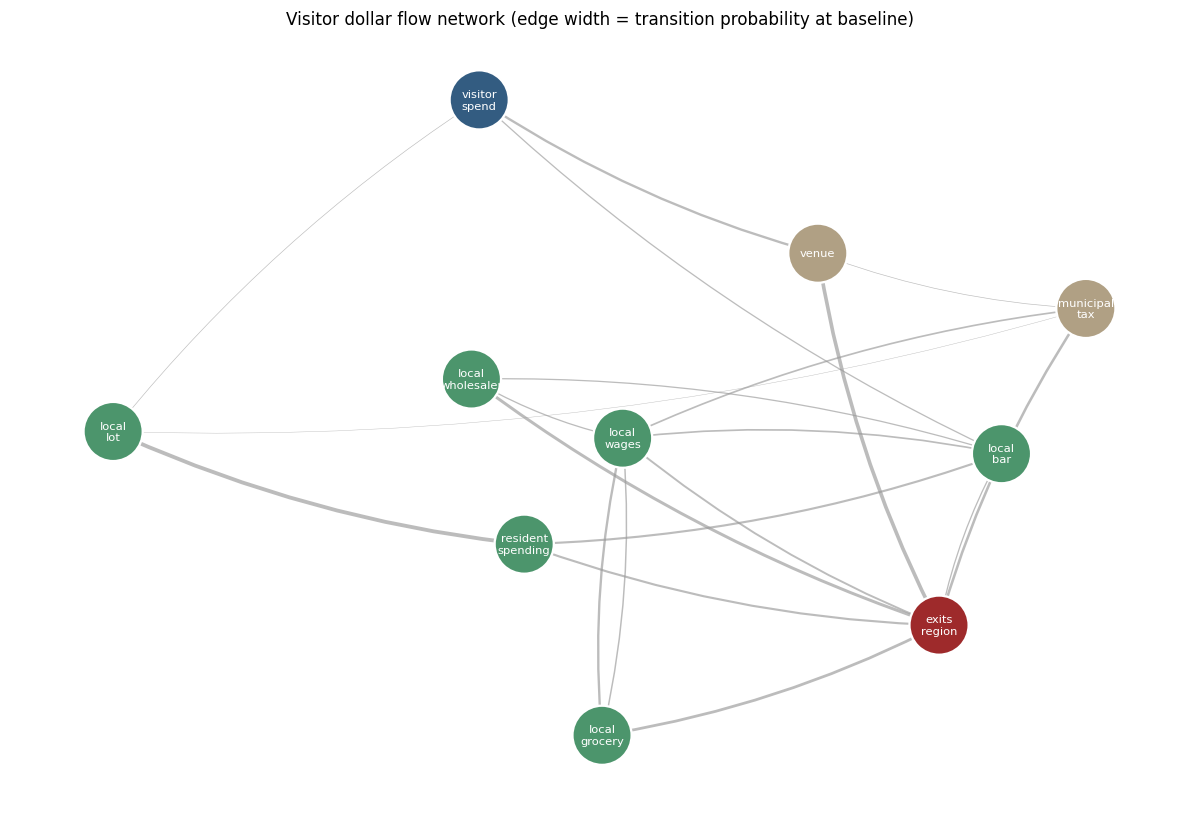

In [4]:
G = nx.DiGraph()
for i, s in enumerate(states):
    for j, t in enumerate(states):
        if P[i, j] > 0 and not (s == t):
            G.add_edge(s, t, weight=P[i, j])

def node_color(n):
    if n in L.LOCAL_NODES:
        return "#4c956c"
    if n == "exits_region":
        return "#9e2a2b"
    if n == "visitor_spend":
        return "#335c81"
    return "#b0a084"

pos = nx.spring_layout(G, k=2.2, seed=11, iterations=200)
fig, ax = plt.subplots(figsize=(11, 7.5))

widths = [2.8 * G[u][v]["weight"] for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, ax=ax, width=widths, edge_color="#999999",
                       arrowsize=13, alpha=0.65, connectionstyle="arc3,rad=0.08")
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=1500,
                       node_color=[node_color(n) for n in G.nodes()],
                       edgecolors="white", linewidths=1.5)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7.5, font_color="white",
                        labels={n: n.replace("_", "\n") for n in G.nodes()})
ax.set_title("Visitor dollar flow network (edge width = transition probability at baseline)",
             fontsize=11)
ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Analytic solution and validation

The expected number of visits to each transient state before absorption is given by the
fundamental matrix. Monte Carlo simulation of 100,000 individual dollar trajectories is
run only to confirm the linear algebra is correct — agreement to three decimal places
is the expected result, not a finding.

In [5]:
analytic = L.retention_metrics(L.BASELINE)
monte_carlo = L.simulate(L.BASELINE, n_dollars=100_000, seed=7)

comparison = pd.DataFrame({
    "analytic": analytic,
    "monte_carlo": monte_carlo,
})
comparison["abs_diff"] = (comparison["analytic"] - comparison["monte_carlo"]).abs()
comparison

,analytic,monte_carlo,abs_diff
local_transactions,1.1833,1.1835,0.0003
steps_to_exit,2.8308,2.8279,0.0029
p_touches_local,0.4830,0.4840,0.0010


In [6]:
N, transient = L.fundamental_matrix(P, states)
start = transient.index("visitor_spend")

visits = pd.DataFrame({
    "expected_visits": N[start, :],
}, index=transient).sort_values("expected_visits", ascending=False)
visits["is_local"] = [s in L.LOCAL_NODES for s in visits.index]
visits

,expected_visits,is_local
visitor_spend,1.0000,False
venue,0.5500,False
local_bar,0.3675,True
local_wages,0.2713,True
local_lot,0.1500,True
local_grocery,0.1492,True
resident_spending,0.1350,True
local_wholesaler,0.1102,True
municipal_tax,0.0975,False


### Why the metric choice matters

At baseline, roughly 48% of dollars *touch* a local business at some point, but the
expected number of local transactions per dollar is about 1.18. Those two numbers tell
different stories. The first suggests about half the money reaches the community; the
second says the average dollar generates barely more than one local transaction before
leaving — which, in local-multiplier terms, is very little recirculation.

Reporting the touch probability would overstate community benefit substantially. This is
the kind of measurement choice that determines whether an impact study finds an effect.

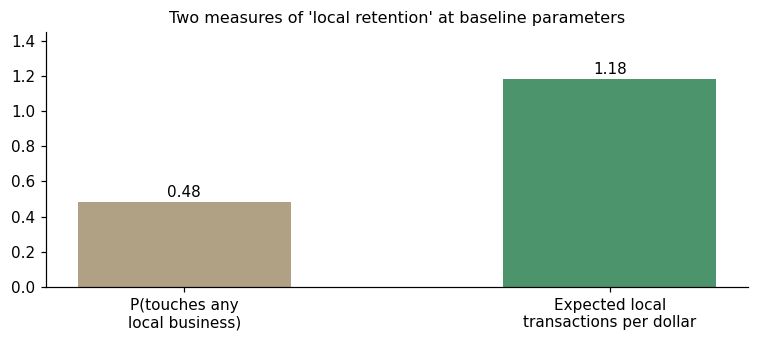

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.2))
vals = [analytic["p_touches_local"], analytic["local_transactions"]]
labels = ["P(touches any\nlocal business)", "Expected local\ntransactions per dollar"]
bars = ax.bar(labels, vals, color=["#b0a084", "#4c956c"], width=0.5)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.03, f"{v:.2f}", ha="center", fontsize=10)
ax.set_ylim(0, 1.45)
ax.set_title("Two measures of 'local retention' at baseline parameters", fontsize=10.5)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Sensitivity analysis

This is the substance of the notebook. Each parameter is swept across a plausible range
while the others are held at baseline. The question is not what retention *is* but what
it *depends on*.

In [8]:
elast = L.elasticity_table()
elast

,parameter,low,high,swing,swing_pct_of_baseline
0,p_venue,0.7528,1.9007,1.1479,97.0149
1,p_bar,1.0716,1.3322,0.2606,22.0209
2,bar_wages,1.0775,1.2891,0.2116,17.8849
3,wage_local,1.0810,1.2826,0.2016,17.0401
4,bar_supply,1.0964,1.2701,0.1737,14.6829
5,resident_local,1.1076,1.2589,0.1512,12.7814
6,venue_leak,1.1410,1.2888,0.1478,12.4910
7,tax_local,1.1271,1.2394,0.1123,9.4899
8,wholesale_local,1.1409,1.2256,0.0847,7.1539


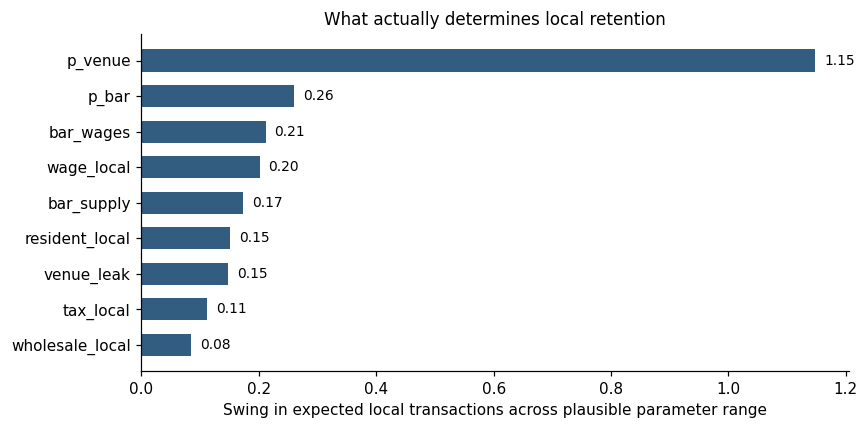

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
e = elast.sort_values("swing")
ax.barh(e["parameter"], e["swing"], color="#335c81", height=0.62)
ax.set_xlabel("Swing in expected local transactions across plausible parameter range")
ax.set_title("What actually determines local retention", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
for i, (p, s) in enumerate(zip(e["parameter"], e["swing"])):
    ax.text(s + 0.015, i, f"{s:.2f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

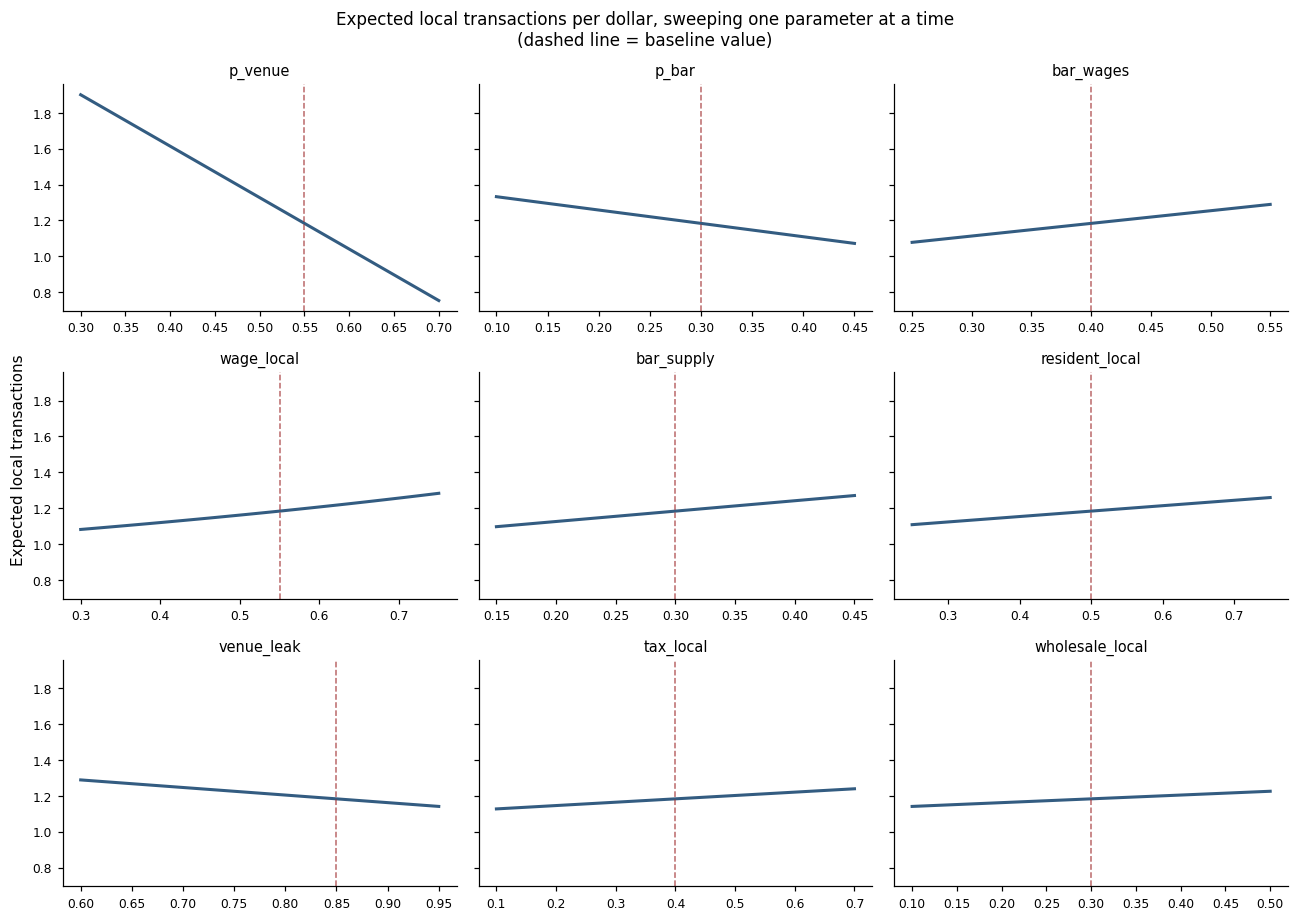

In [10]:
sweep = L.one_at_a_time(n=40)

fig, axes = plt.subplots(3, 3, figsize=(12, 8.5), sharey=True)
order = list(elast["parameter"])
for ax, param in zip(axes.ravel(), order):
    sub = sweep[sweep["parameter"] == param]
    ax.plot(sub["value"], sub["local_transactions"], color="#335c81", lw=2)
    ax.axvline(L.BASELINE[param], color="#9e2a2b", ls="--", lw=1, alpha=0.7)
    ax.set_title(param, fontsize=9.5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)
for ax in axes.ravel()[len(order):]:
    ax.axis("off")
fig.suptitle("Expected local transactions per dollar, sweeping one parameter at a time\n"
             "(dashed line = baseline value)", fontsize=11)
fig.supylabel("Expected local transactions", fontsize=10)
plt.tight_layout()
plt.show()

### The finding

**The entry split dominates everything downstream.** The share of visitor spending
captured at the venue and official channels (`p_venue`) produces a swing roughly four
times larger than any other parameter — moving retention from about 0.75 to about 1.90
expected local transactions across its plausible range.

Every downstream recirculation parameter — how much independent businesses pay in local
wages, how much of those wages is spent locally, how much the wholesaler sources
regionally — matters considerably less. Individually they move retention by 10–20%.

This has a direct implication for the supplier programs several 2026 host cities
implemented. Those programs operate downstream: they try to insert local businesses into
the procurement chain *after* the spending has entered official channels. If this
structure is even roughly right, that is the lower-leverage intervention. The higher-
leverage one is whether the spending enters official channels at all — which is
determined by venue design, event-day transport, ticketing bundles, and whether the
surrounding district has independent businesses that visitors can reach.

That conclusion does not depend on the parameter values being correct. It depends only
on the network structure, which is why the sweep is the analysis.

## 4. Global sensitivity

One-at-a-time sweeps hold everything else fixed and can miss interactions. Sampling the
full parameter space uniformly within the plausible ranges gives the distribution of
outcomes a reader should actually expect.

In [11]:
samples = L.global_sample(n=20_000, seed=1)
print(samples["local_transactions"].describe().to_string())

count   20,000.0000
mean         1.4087
std          0.3395
min          0.5792
25%          1.1423
50%          1.4009
75%          1.6595
max          2.6191


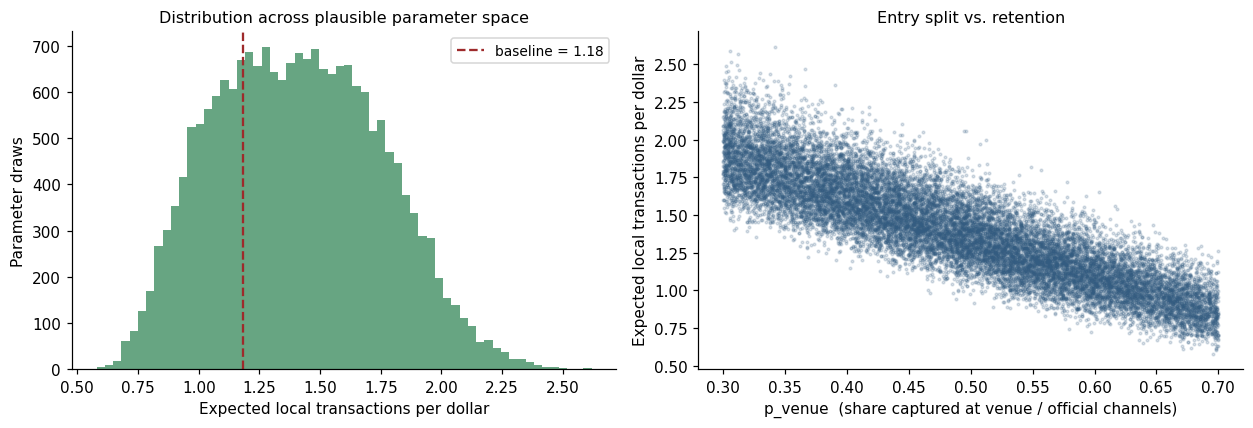

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))

axes[0].hist(samples["local_transactions"], bins=60, color="#4c956c", alpha=0.85)
axes[0].axvline(analytic["local_transactions"], color="#9e2a2b", ls="--", lw=1.5,
                label=f"baseline = {analytic['local_transactions']:.2f}")
axes[0].set_xlabel("Expected local transactions per dollar")
axes[0].set_ylabel("Parameter draws")
axes[0].set_title("Distribution across plausible parameter space", fontsize=10.5)
axes[0].legend(fontsize=9)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].scatter(samples["p_venue"], samples["local_transactions"], s=3, alpha=0.18,
                color="#335c81")
axes[1].set_xlabel("p_venue  (share captured at venue / official channels)")
axes[1].set_ylabel("Expected local transactions per dollar")
axes[1].set_title("Entry split vs. retention", fontsize=10.5)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [13]:
corr = (samples[list(L.RANGES)]
        .corrwith(samples["local_transactions"])
        .sort_values(key=abs, ascending=False)
        .rename("correlation_with_retention")
        .to_frame())
corr

,correlation_with_retention
p_venue,-0.8744
resident_local,0.2079
bar_wages,0.1855
wage_local,0.1808
bar_supply,0.1556
tax_local,0.1300
venue_leak,-0.1087
wholesale_local,0.0705
p_bar,-0.0553


The global sample confirms the one-at-a-time result. Across 20,000 draws from the full
parameter space, `p_venue` correlates with retention far more strongly than any other
parameter, and the relationship is close to monotonic. Interactions between parameters do
not change the ordering.

## 5. Limitations

These matter and should be read before the findings are used for anything.

**The structure is assumed, not estimated.** The nodes and the edges between them are a
stylised representation of a stadium-district economy. A different plausible structure
could produce different conclusions. The parameter sweep addresses uncertainty in the
values, not in the topology.

**No data.** Nothing here is calibrated against observed spending. The ranges are chosen
to bound what a reader might find defensible, not estimated from evidence. The natural
next step is calibration against BEA input-output tables, County Business Patterns
establishment data, and the local-multiplier literature (LM3 and related).

**Dollars are treated as indivisible tokens.** Real transactions split — a bar pays wages
*and* suppliers *and* rent from the same revenue. The Markov formulation tracks a unit of
currency along one path; expected visit counts are still correct in aggregate, but the
model cannot represent proportional splitting within a single transaction.

**No time, no capacity, no congestion.** Velocity of money in the Fisher sense is
transactions per unit time; this model has no time dimension and the "steps" metric is
path length, not velocity. Nothing constrains how much a node can absorb.

**No distributional detail.** Local wages are a single node. Who receives them, and
whether the recipients live in the affected neighborhood, is exactly the question that
matters for whether an event benefits the community — and this model cannot address it.

## 6. What would make this real

1. **Calibrate the entry split.** Transaction-level or card-panel data for a stadium
   district before, during, and after an event date would identify `p_venue` directly.
   That single parameter drives most of the variance.
2. **Estimate recirculation from I-O tables.** BEA regional input-output accounts provide
   sector-to-sector coefficients that map onto the downstream edges.
3. **Add ownership.** Independent versus chain, and resident versus non-resident ownership,
   determine whether a transaction is local in the sense that matters.
4. **Test against a real event.** The 2026 World Cup host cities implemented supplier
   programs with different designs. Comparing retention across cities that did and did not
   would be an actual natural experiment, and Los Angeles 2028 offers a chance to
   instrument before rather than reconstruct after.